# Predictive Mini-Overfit Dashboard (STEP 5)

**Technical** learnability check for the 4 predictive models on `data_training_full_rebuilt/`.
NOT accuracy, NOT LOSO, NOT final training. Configure below, optionally launch, then view results.

In [1]:
# === CONFIG ===
RUN          = False   # True -> launch the mini-overfit script; False -> load existing results
DATA_DIR     = 'data_training_full_rebuilt'
MODALITIES   = ['mouse', 'keyboard', 'notif', 'switching']
NUM_SAMPLES  = 32
EPOCHS       = 300
BATCH_SIZE   = 32
LR           = 1e-3
DEVICE       = 'cuda'
SEED         = 42
import sys, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
OUT = ROOT/'outputs/predictive_mini_overfit'
print('output dir:', OUT)

output dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\predictive_mini_overfit


In [2]:
if RUN:
    cmd = [sys.executable, str(ROOT/'scripts/predictive/mini_overfit_predictive_models.py'),
           '--data-dir', str(ROOT/DATA_DIR), '--output-dir', str(OUT),
           '--modalities', *MODALITIES, '--num-samples', str(NUM_SAMPLES),
           '--epochs', str(EPOCHS), '--lr', str(LR), '--device', DEVICE, '--seed', str(SEED)]
    print('running:', ' '.join(cmd)); subprocess.run(cmd, check=True, cwd=str(ROOT))
else:
    print('Loading existing results (RUN=False).')

Loading existing results (RUN=False).


## Global PASS/FAIL summary

In [3]:
summary = json.load(open(OUT/'mini_overfit_summary.json'))
print('predictive_final_training_allowed:', summary['predictive_final_training_allowed'])
df = pd.read_csv(OUT/'mini_overfit_summary.csv')
df[['modality','status','initial_loss','final_loss','loss_reduction_ratio','reload_ok','output_shape_ok','nan_or_inf','fail_reason']]

predictive_final_training_allowed: True


,modality,status,initial_loss,final_loss,loss_reduction_ratio,reload_ok,output_shape_ok,nan_or_inf,fail_reason
0,mouse,PASS,1.714809,0.000105,0.0001,True,True,False,NaN
1,keyboard,PASS,1.772275,0.000130,0.0001,True,True,False,NaN
2,notif,PASS,1.710227,0.000312,0.0002,True,True,False,NaN
3,switching,PASS,1.741645,0.000246,0.0001,True,True,False,NaN


## Subset used

In [4]:
sub = pd.read_csv(OUT/'mini_overfit_subset.csv')
print('n=', len(sub), '| users:', sub['user_id'].nunique(), '| states:', dict(sub['state_label'].value_counts().sort_index()))
sub.head(10)

n= 32 | users: 13 | states: {0: 4, 1: 11, 2: 9, 3: 6, 4: 2}


,row_idx,session_id,user_id,device_id,window_id,window_start,window_end,state_label,factor_mental,factor_temporal,factor_effort,factor_frustration,factor_arousal,dual_task_available
0,0,session_20260510_191823_9a2425,dem,browser_mp03ekmbeazr37,w000000,1.778437e+09,1.778437e+09,1,0.53,0.60,0.50,0.18,0.550,False
1,16,session_20260510_195504_b593cc,dem,browser_mp03ekmbeazr37,w000000,1.778439e+09,1.778439e+09,0,0.22,0.22,0.27,0.24,0.245,False
2,49,session_20260511_184052_938a4e,mohanned,browser_molyfx8zeb2zr1,w000000,1.778521e+09,1.778521e+09,1,0.58,0.60,0.57,0.44,0.585,False
3,65,session_20260513_110323_584cf7,layss,device_9474033c,w000000,1.778667e+09,1.778667e+09,2,0.01,0.01,0.00,0.00,0.005,False
4,72,session_20260515_222916_e5858b,Graja,device_6efd56b1,w000000,1.778881e+09,1.778881e+09,2,0.20,0.05,0.35,0.20,0.200,False
5,83,session_20260516_105315_535a79,hffz,device_6dd3e3f6,w000000,1.778925e+09,1.778925e+09,0,0.52,0.04,0.18,0.26,0.110,False
6,91,session_20260516_105702_81c740,browser_mp835qq4j4kymt,browser_mp835qq4j4kymt,w000000,1.778925e+09,1.778926e+09,1,0.96,0.49,0.64,0.29,0.565,False
7,99,session_20260516_110318_a84820,amrdroid,browser_mp86g429xypxnh,w000000,1.778926e+09,1.778926e+09,1,0.70,0.62,0.45,0.77,0.535,False
8,200,session_20260517_113407_c4efba,dem,browser_mp03ekmbeazr37,w000000,1.779014e+09,1.779014e+09,3,0.58,0.74,0.64,0.28,0.690,False
9,231,session_20260517_134333_aeb7dc,browser_mp8quvqu5u5czy,browser_mp8quvqu5u5czy,w000000,1.779022e+09,1.779022e+09,3,1.00,1.00,0.73,0.11,0.865,False


## Loss curves (all modalities)

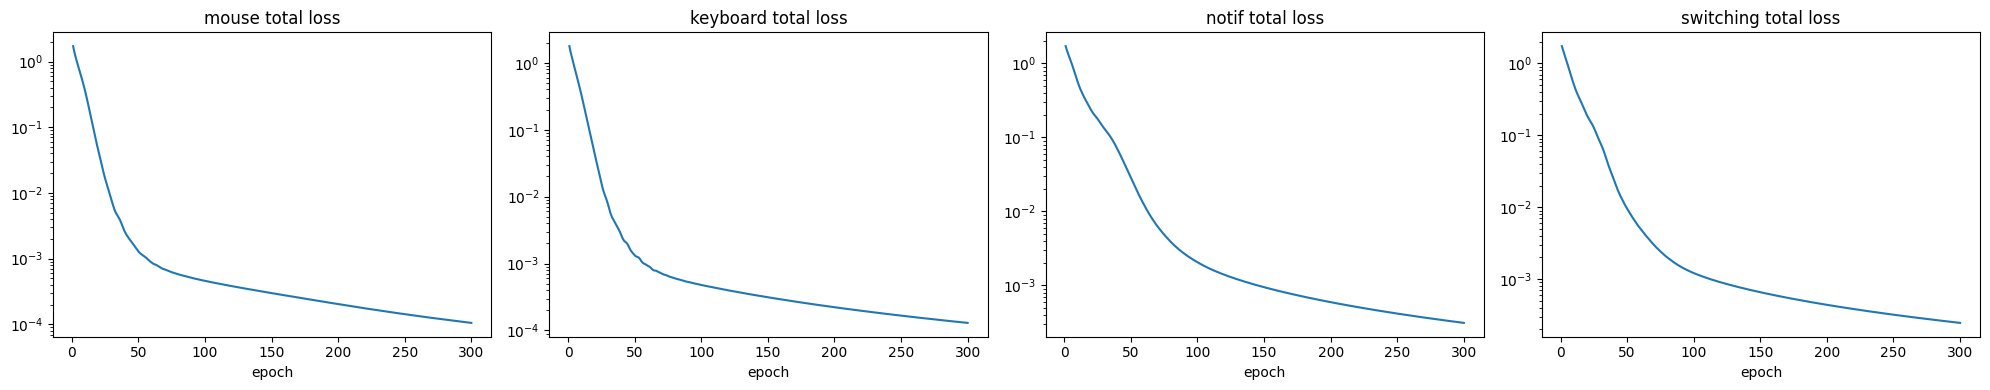

In [5]:
fig, ax = plt.subplots(1, len(MODALITIES), figsize=(5*len(MODALITIES), 4))
if len(MODALITIES)==1: ax=[ax]
for a, m in zip(ax, MODALITIES):
    h = pd.read_csv(OUT/m/'loss_history.csv')
    a.plot(h['epoch'], h['total_loss']); a.set_title(f'{m} total loss'); a.set_yscale('log'); a.set_xlabel('epoch')
plt.tight_layout(); plt.show()

## Per-modality plots (loss / factor pred-vs-true / confusion / output dist / grad)

======================================== mouse ========================================


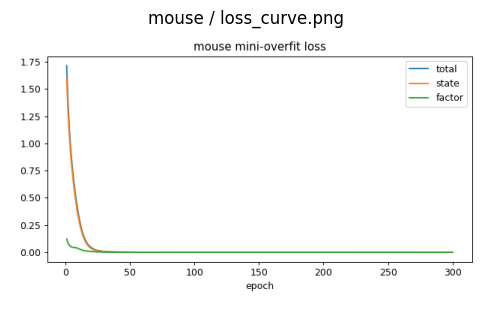

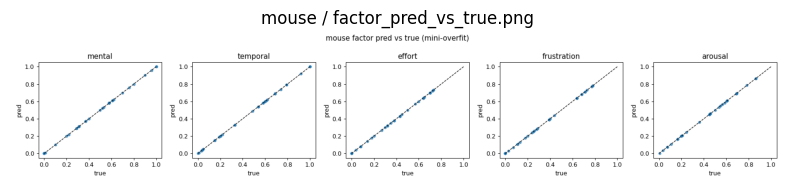

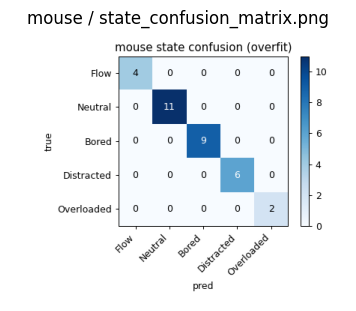

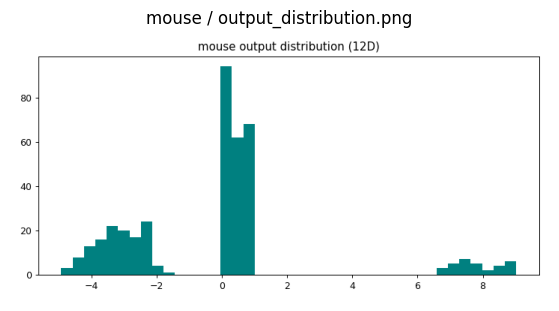

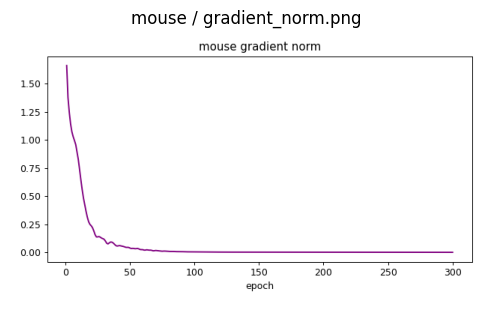

======================================== keyboard ========================================


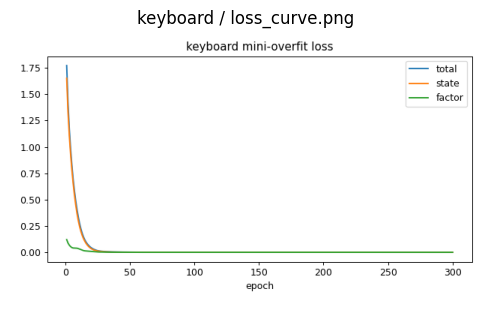

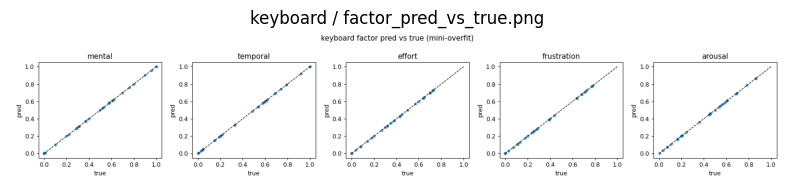

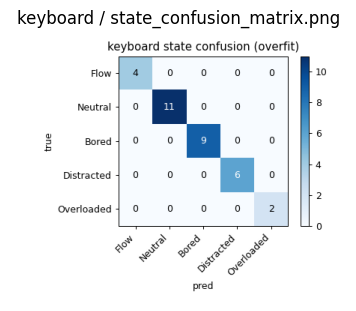

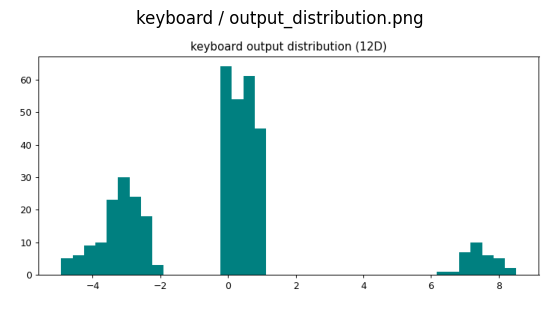

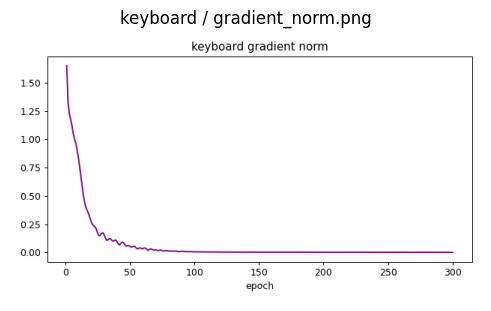

======================================== notif ========================================


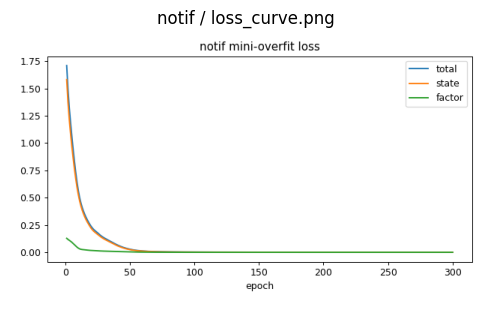

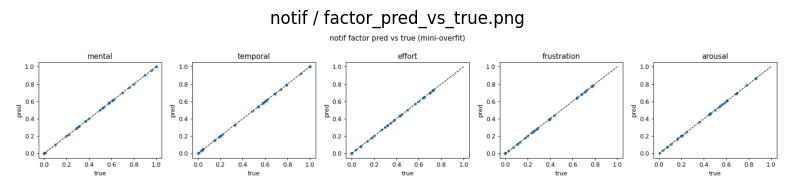

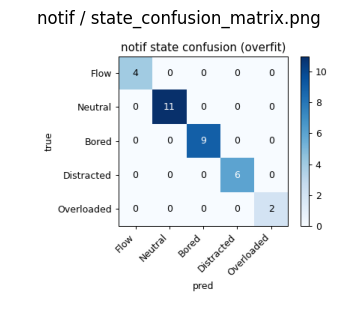

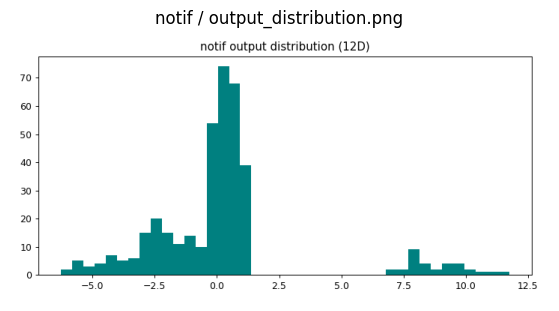

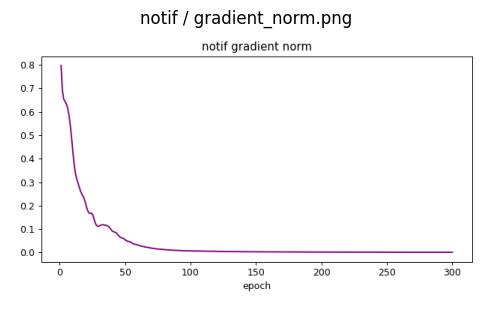

======================================== switching ========================================


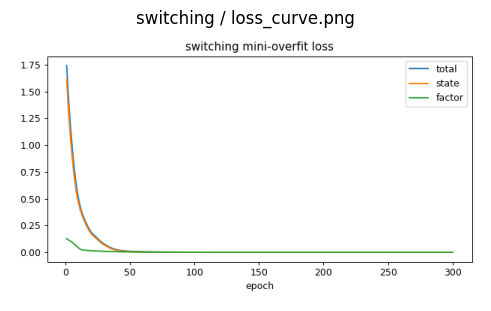

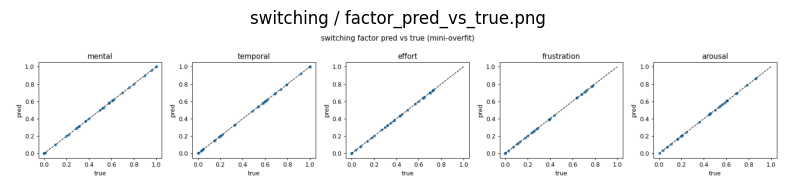

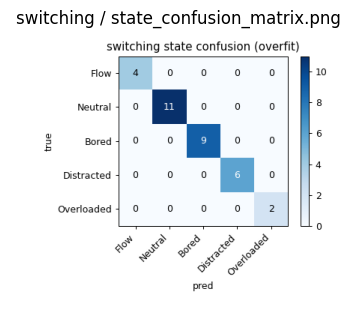

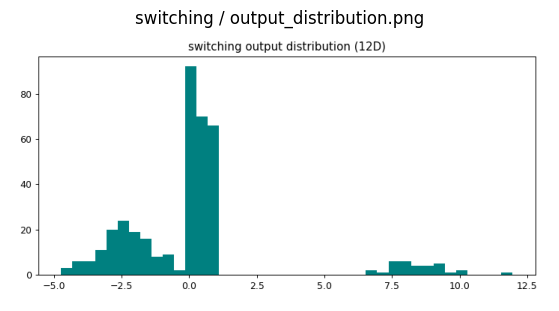

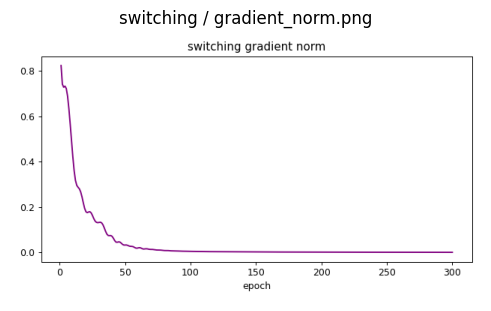

In [6]:
def show(m):
    imgs = ['loss_curve.png','factor_pred_vs_true.png','state_confusion_matrix.png','output_distribution.png','gradient_norm.png']
    for im in imgs:
        p = OUT/m/im
        if p.exists():
            plt.figure(figsize=(10,3.5)); plt.imshow(Image.open(p)); plt.axis('off'); plt.title(f'{m} / {im}'); plt.show()
for m in MODALITIES:
    print('='*40, m, '='*40); show(m)

## Reload checks

In [7]:
for m in MODALITIES:
    rc = json.load(open(OUT/m/'reload_check.json'))
    print(f'{m:10s} reload_ok={rc["reload_ok"]}  max_abs_diff={rc["max_abs_diff"]:.2e}')

mouse      reload_ok=True  max_abs_diff=0.00e+00
keyboard   reload_ok=True  max_abs_diff=0.00e+00
notif      reload_ok=True  max_abs_diff=0.00e+00
switching  reload_ok=True  max_abs_diff=0.00e+00


## Interpretation
This validates **technical learnability only** (loader, slice indexing, forward/loss/grads, optimizer,
checkpoint reload, (B,12) contract, no NaN/Inf). Near-zero loss is expected — it is a 32-sample overfit.
It is **not** accuracy and does **not** replace final session-split / LOSO training. See
`outputs/predictive_mini_overfit/MINI_OVERFIT_PREDICTIVE_REPORT.md`.